# Metrics comparison between symbolic and numerical IK 

## Imports 

In [57]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metrics import l2_error, rodrigues_error, combined_error

In [58]:
test = "line"

filepath_sym = f'data/num_{test}_data.csv'
filepath_num = f'data/qp_{test}_data.csv'

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()

display(df_sym.head(3))
df_sym.info()
df_num.info()

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,r_q2,r_q3,r_q4,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose
0,0.000000,-1.955021,13.721056,25.526418,-85.170895,-17.063143,2.049288,26.643318,-1.952270,-13.726654,-25.520315,-85.170861,17.057313,2.047254,-26.649843,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-7.881707120294124e-09, 1.763354402175384e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[1.620034756344424e-08, 1.1792983414014841e-0..."
1,0.008333,-1.949496,13.661321,25.476751,-85.259489,-17.007028,2.118583,26.615203,-1.946646,-13.666198,-25.470062,-85.260596,17.000527,2.117428,-26.621400,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-8.991227173904548e-08, 1.937733592045776e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.3135903737259156e-07, -3.7881433138969077..."
2,0.016667,-1.943807,13.599779,25.425463,-85.350734,-16.949126,2.189999,26.586061,-1.940963,-13.604664,-25.418774,-85.351833,16.942627,2.188851,-26.592252,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-4.484656562775413e-08, 1.3058114269425426e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.452987226091551e-07, -2.697817770359596e-..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         480 non-null    float64
 1   l_q0         480 non-null    float64
 2   l_q1         480 non-null    float64
 3   l_q2         480 non-null    float64
 4   l_q3         480 non-null    float64
 5   l_q4         480 non-null    float64
 6   l_q5         480 non-null    float64
 7   l_q6         480 non-null    float64
 8   r_q0         480 non-null    float64
 9   r_q1         480 non-null    float64
 10  r_q2         480 non-null    float64
 11  r_q3         480 non-null    float64
 12  r_q4         480 non-null    float64
 13  r_q5         480 non-null    float64
 14  r_q6         480 non-null    float64
 15  l_pose       480 non-null    object 
 16  l_real_pose  480 non-null    object 
 17  r_pose       480 non-null    object 
 18  r_real_pose  480 non-null    object 
dtypes: float

In [59]:
def parse_pose_matrix(matrix_str):
    """Convert a string of a matrix into a NumPy array."""
    return np.array(ast.literal_eval(matrix_str))

In [60]:
l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_sym.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])
    l_comb = combined_error(l_pos, l_rot)

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)
    l_comb_errs.append(l_comb)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])
    r_comb = combined_error(r_pos, r_rot)

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)
    r_comb_errs.append(r_comb)

df_sym["l_pos_err"] = l_pos_errs
df_sym["l_rot_err"] = l_rot_errs
df_sym["l_combined_err"] = l_comb_errs

df_sym["r_pos_err"] = r_pos_errs
df_sym["r_rot_err"] = r_rot_errs
df_sym["r_combined_err"] = r_comb_errs

display(df_sym.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,l_combined_err,r_pos_err,r_rot_err,r_combined_err
0,0.000000,-1.955021,13.721056,25.526418,-85.170895,-17.063143,2.049288,26.643318,-1.952270,-13.726654,...,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-7.881707120294124e-09, 1.763354402175384e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[1.620034756344424e-08, 1.1792983414014841e-0...",5.898167e-09,2.058382e-08,6.014922e-09,7.294283e-09,2.200233e-08,7.402417e-09
1,0.008333,-1.949496,13.661321,25.476751,-85.259489,-17.007028,2.118583,26.615203,-1.946646,-13.666198,...,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-8.991227173904548e-08, 1.937733592045776e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.3135903737259156e-07, -3.7881433138969077...",1.131782e-05,2.162023e-07,1.131783e-05,3.083815e-05,4.549127e-07,3.083816e-05
2,0.016667,-1.943807,13.599779,25.425463,-85.350734,-16.949126,2.189999,26.586061,-1.940963,-13.604664,...,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-4.484656562775413e-08, 1.3058114269425426e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.452987226091551e-07, -2.697817770359596e-...",6.858096e-06,1.446641e-07,6.858101e-06,1.868328e-05,3.179946e-07,1.868329e-05


In [61]:
l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_num.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_num["l_pos_err"] = l_pos_errs
df_num["l_rot_err"] = l_rot_errs

df_num["r_pos_err"] = r_pos_errs
df_num["r_rot_err"] = r_rot_errs

display(df_num.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,r_pos_err,r_rot_err
0,0.000000,-2.992973,11.702563,27.755486,-85.170895,-19.222661,2.814486,24.306357,-2.991219,-11.705827,...,2.813113,-24.310216,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-5.993945895177433e-10, -2.673095726771482e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-3.7612942760389956e-09, 9.503629333453271e-...",6.572162e-09,2.737125e-08,1.550764e-09,1.446706e-08
1,0.008333,-2.998356,11.616492,27.730414,-85.260889,-19.189504,2.891160,24.252144,-2.995279,-11.622225,...,2.888795,-24.258863,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.613213584412577e-08, -1.1227042853690703e...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-5.300815641984258e-08, 2.1948929343859683e-...",6.293014e-06,3.406819e-08,2.916100e-05,6.111325e-08
2,0.016667,-3.002214,11.532137,27.701193,-85.352127,-19.152259,2.967689,24.200496,-2.999265,-11.538502,...,2.964602,-24.207425,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.1039803238244161e-08, -1.7848119847203697...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-8.070247098368455e-08, 6.689095954682364e-0...",6.299861e-06,2.104228e-08,2.916048e-05,8.294990e-08


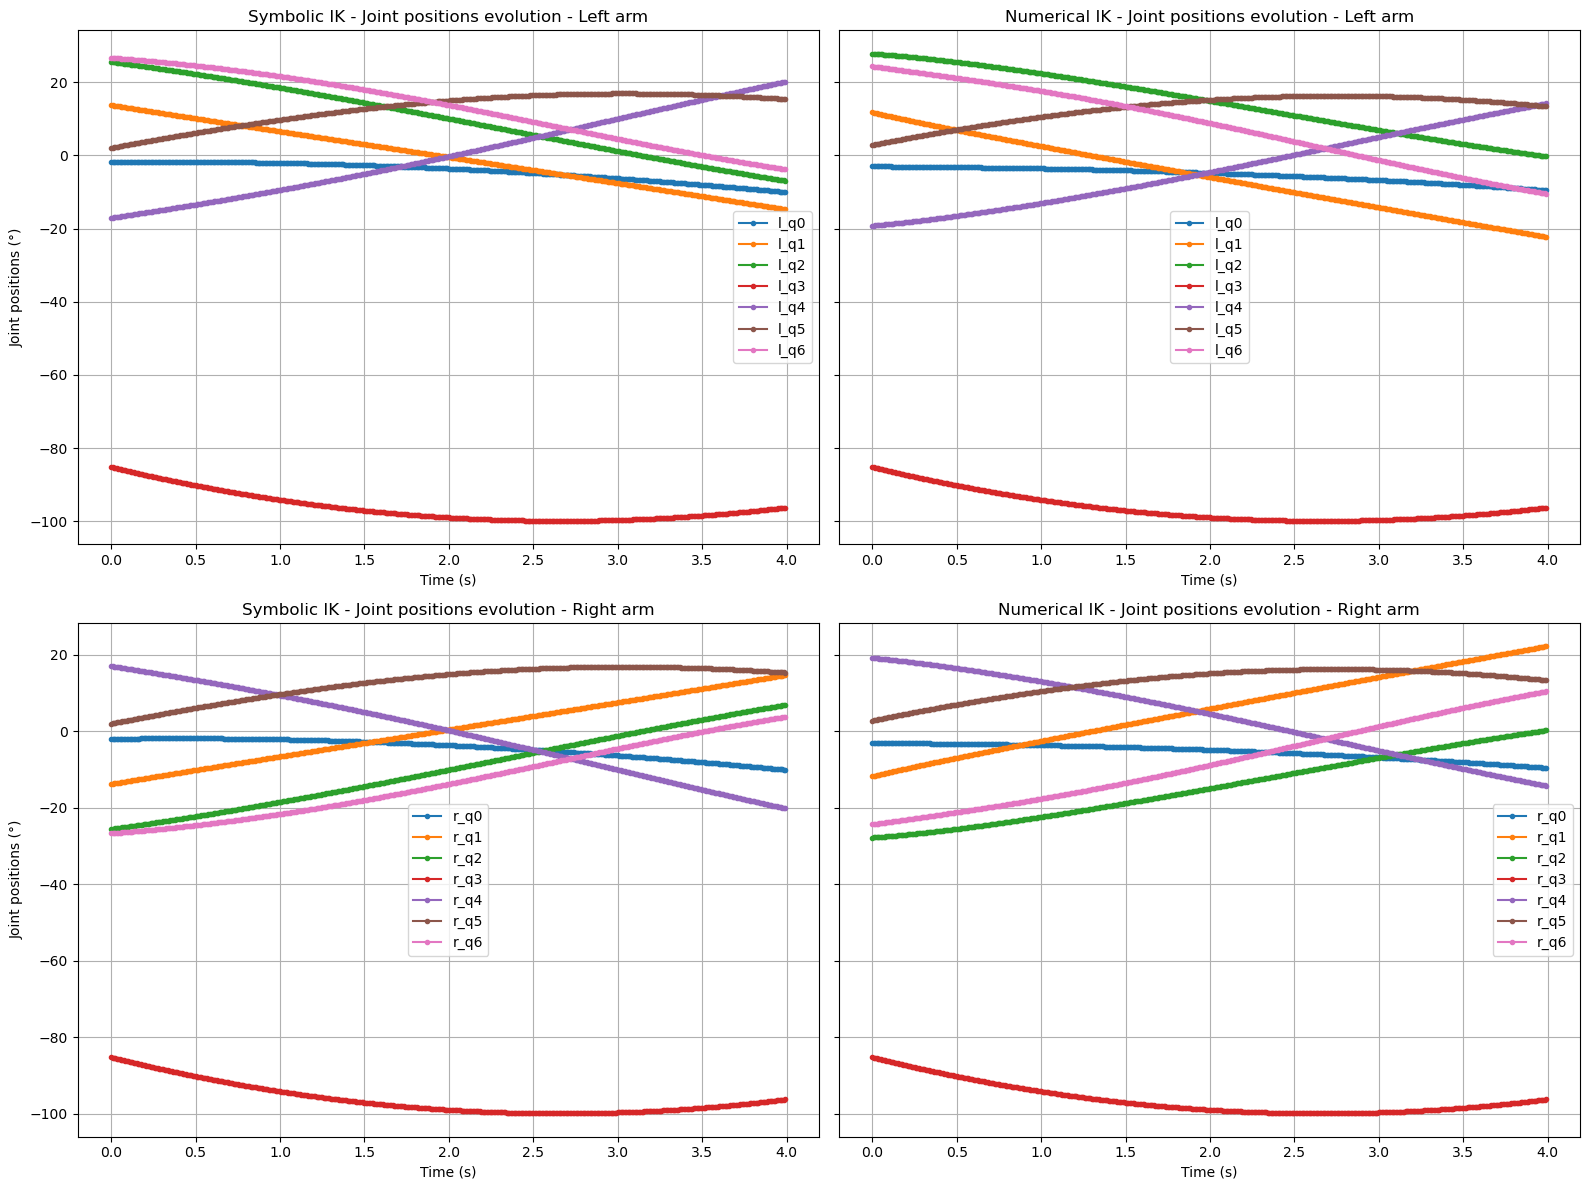

In [62]:
l_joint_cols = ["l_q0", "l_q1", "l_q2", "l_q3", "l_q4", "l_q5", "l_q6"]
r_joint_cols = ["r_q0", "r_q1", "r_q2", "r_q3", "r_q4", "r_q5", "r_q6"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey='row')

for col in l_joint_cols:
    axes[0, 0].plot(df_sym["time"], df_sym[col], label=col, marker='.')
axes[0, 0].set_title("Symbolic IK - Joint positions evolution - Left arm")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Joint positions (°)")
axes[0, 0].legend()
axes[0, 0].grid(True)

for col in l_joint_cols:
    axes[0, 1].plot(df_num["time"], df_num[col], label=col, marker='.')
axes[0, 1].set_title("Numerical IK - Joint positions evolution - Left arm")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].legend()
axes[0, 1].grid(True)

for col in r_joint_cols:
    axes[1, 0].plot(df_sym["time"], df_sym[col], label=col, marker='.')
axes[1, 0].set_title("Symbolic IK - Joint positions evolution - Right arm")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Joint positions (°)")
axes[1, 0].legend()
axes[1, 0].grid(True)

for col in r_joint_cols:
    axes[1, 1].plot(df_num["time"], df_num[col], label=col, marker='.')
axes[1, 1].set_title("Numerical IK - Joint positions evolution - Right arm")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].legend()
axes[1, 1].grid(True)


plt.tight_layout()
plt.show()

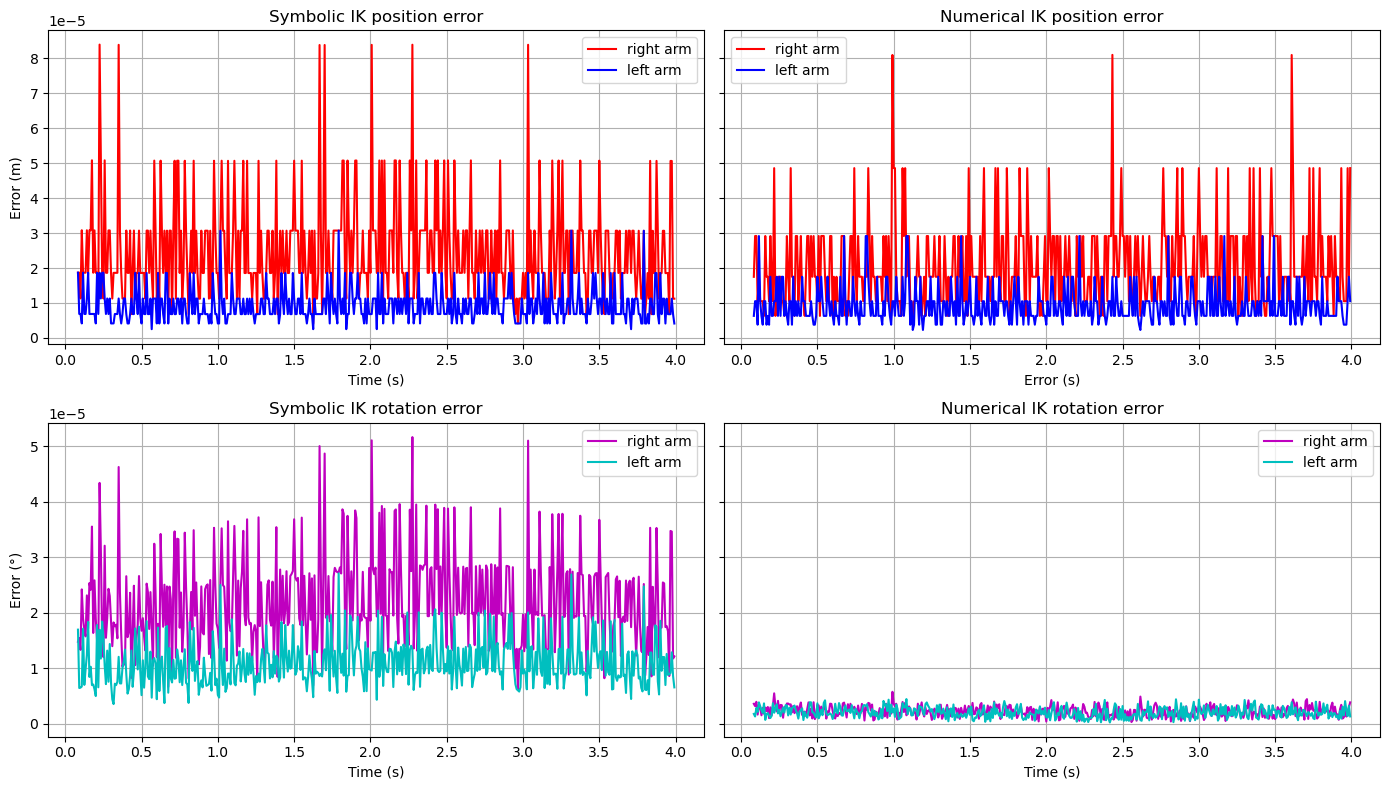

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey='row')

axes[0, 0].plot(df_sym["time"][10:], df_sym["r_pos_err"][10:], label="right arm", color="red")
axes[0, 0].plot(df_sym["time"][10:], df_sym["l_pos_err"][10:], label="left arm", color="blue")
axes[0, 0].set_title("Symbolic IK position error")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Error (m)")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(df_num["time"][10:], df_num["r_pos_err"][10:], label="right arm", color="red")
axes[0, 1].plot(df_num["time"][10:], df_num["l_pos_err"][10:], label="left arm", color="blue")
axes[0, 1].set_title("Numerical IK position error")
axes[0, 1].set_xlabel("Error (s)")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(df_sym["time"][10:], np.rad2deg(df_sym["r_rot_err"][10:]), label="right arm", color="m")
axes[1, 0].plot(df_sym["time"][10:], np.rad2deg(df_sym["l_rot_err"][10:]), label="left arm", color="c")
axes[1, 0].set_title("Symbolic IK rotation error")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Error (°)")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(df_num["time"][10:], np.rad2deg(df_num["r_rot_err"][10:]), label="right arm", color="m")
axes[1, 1].plot(df_num["time"][10:], np.rad2deg(df_num["l_rot_err"][10:]), label="left arm", color="c")
axes[1, 1].set_title("Numerical IK rotation error")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


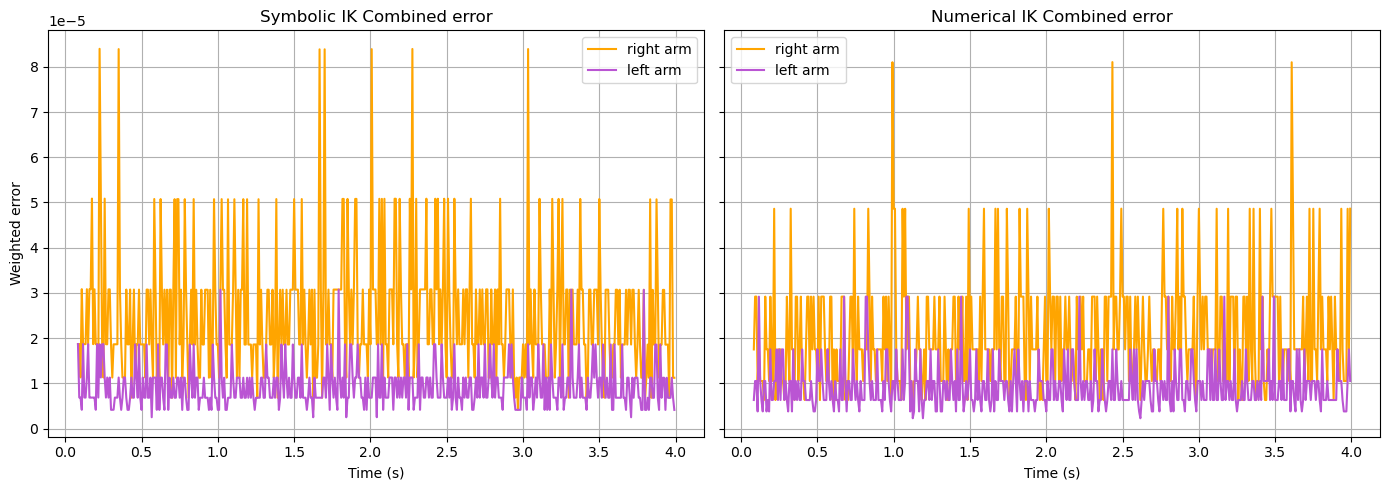

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

lambda_theta = 1e-6 / np.deg2rad(1) ** 2

axes[0].plot(df_sym["time"][10:], combined_error(df_sym["r_pos_err"], df_sym["r_rot_err"], lambda_theta=lambda_theta)[10:], label="right arm", color="orange")
axes[0].plot(df_sym["time"][10:], combined_error(df_sym["l_pos_err"], df_sym["l_rot_err"], lambda_theta=lambda_theta)[10:], label="left arm", color="mediumorchid")
axes[0].set_title("Symbolic IK Combined error")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Weighted error")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df_num["time"][10:], combined_error(df_num["r_pos_err"], df_num["r_rot_err"], lambda_theta=lambda_theta)[10:], label="right arm", color="orange")
axes[1].plot(df_num["time"][10:], combined_error(df_num["l_pos_err"], df_num["l_rot_err"], lambda_theta=lambda_theta)[10:], label="left arm", color="mediumorchid")
axes[1].set_title("Numerical IK Combined error")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Parameters influence 

### Proportionnal corrector $K_p$

In [65]:
method = "num"

mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for kp in ["0010", "0025", "0050", "0075", "0100", "0125", "0150", "0175", "0200", "0300", "0400", "0500", "0600", "0750", "1000"]:
    filepath_num = f'data/{method}_circle_data_kp{kp}.csv'
    df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())
    

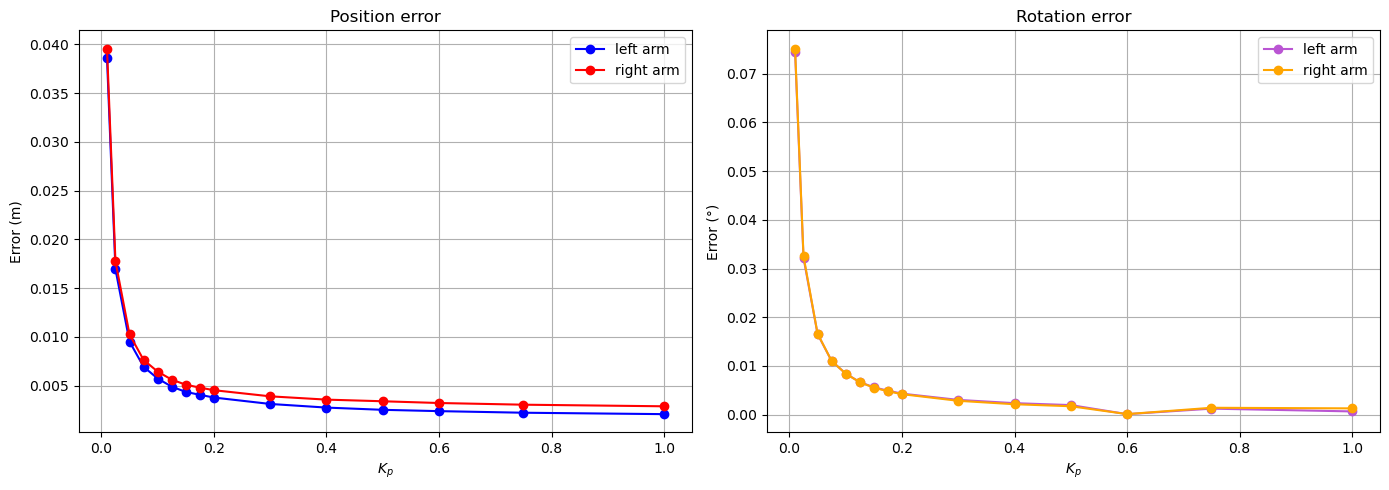

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Kp = [0.01, 0.025, 0.050, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.3, 0.4, 0.5, 0.6, 0.75, 1.0]

axes[0].plot(Kp, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(Kp, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("$K_p$")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(Kp, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(Kp, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("$K_p$")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


Integration step `ik_step` 

In [67]:

mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for step in ["00010", "00020", "00030", "00040", "00050"]:
    filepath_num = f'data/num_circle_data_ikstep{step}.csv'
    df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())
    

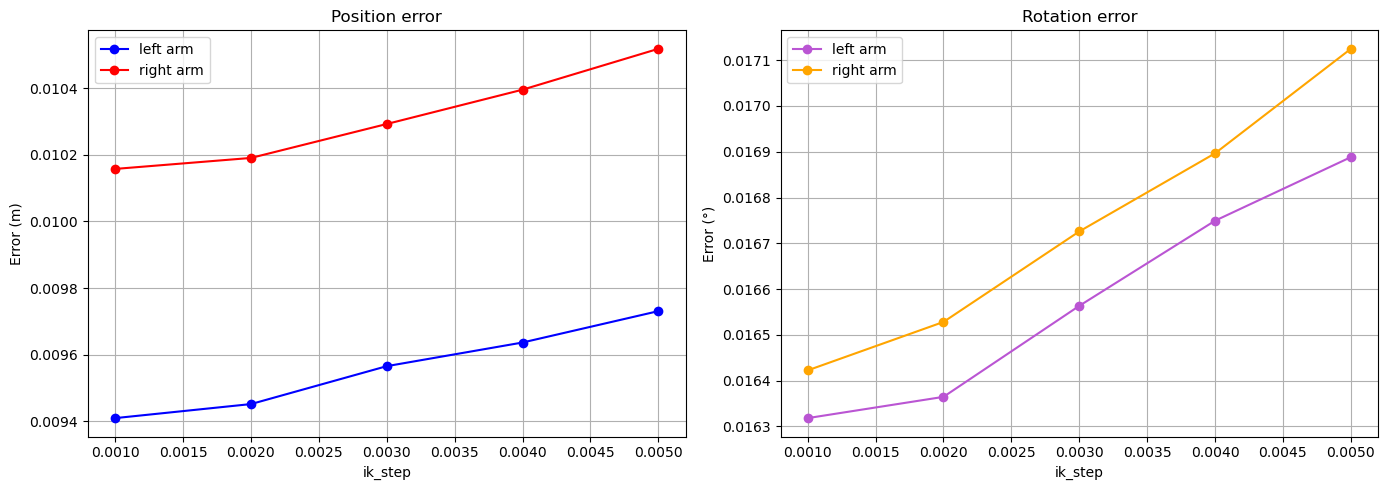

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

step = [0.001, 0.002, 0.003, 0.004, 0.005]

axes[0].plot(step, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(step, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("ik_step")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(step, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(step, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("ik_step")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Damping factor $\lambda$

In [69]:

mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for step in ["075e10", "075e9", "075e8", "075e7", "075e6", "075e5", "075e4", "075e3", "075e2", "075e1"]:
    filepath_num = f'data/num_circle_data_l{step}.csv'
    df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())
    

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_19844/1896034454.py:9: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_xlabel("$\log(\lambda)$")
/tmp/ipykernel_19844/1896034454.py:18: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_xlabel("$\log(\lambda)$")


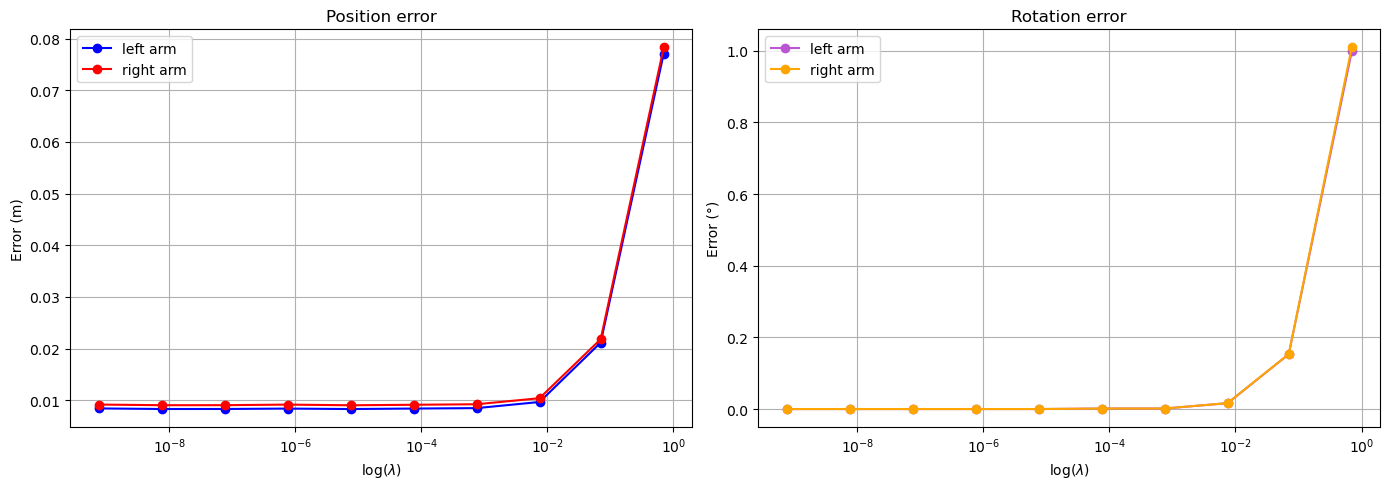

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_lambda = [7.5e-10, 7.5e-9, 7.5e-8, 7.5e-7, 7.5e-6, 7.5e-5, 7.5e-4, 7.5e-3, 7e-2, 7e-1]

axes[0].plot(_lambda, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(_lambda, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("$\log(\lambda)$")
axes[0].set_xscale('log')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(_lambda, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(_lambda, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("$\log(\lambda)$")
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
